IMPORTACION DE LIBRERIAS

In [1]:
# Se importan las librerías.

import pandas as pd                # para manipulación y análisis de datos
import numpy as np                 # para cálculos numéricos y matrices

import matplotlib.pyplot as plt    # para crear gŕaficos visualizaciones
import seaborn as sns              # para gráficos estadísticos más atractivos

# Sklearn
from sklearn.impute import SimpleImputer            # para procesar valores nulos
from sklearn.preprocessing import OneHotEncoder     # para transformar variables
from sklearn.pipeline import Pipeline               # para encadenar procesos secuencialmente
from sklearn.compose import ColumnTransformer       # para trasformaciones especificas a columnas

sns.set(style="whitegrid")         # aplicamos seaborn

CARGA DE DATOS

In [2]:
def cargar_datos(url):
    """ Función que recibe la url del archivo a leer """
    df = pd.read_csv(url)
    print("Dataset cargado correctamente")
    print(df.head())
    return df

EJECUCION

In [3]:
# guardamos la url en una variable
url = "https://raw.githubusercontent.com/magomezn-debug/dScience_001D/main/data/dataset_clientes.csv"

# para cargar datos
df = cargar_datos(url)

Dataset cargado correctamente
   id_cliente fecha_registro  edad     genero  region estado_civil  \
0           1     2021-10-27    66       Otro   Norte   Divorciado   
1           2     2018-08-25    51  Masculino  Centro      Soltero   
2           3     2019-05-25    48   Femenino   Norte       Casado   
3           4     2022-04-20    54  Masculino     Sur       Casado   
4           5     2020-03-19    31       Otro  Centro      Soltero   

   ingreso_mensual  gasto_mensual   deuda_total  score_crediticio  ...  \
0     9.243057e+05  524088.303055  2.448145e+06        455.406680  ...   
1     1.384687e+06  314259.751474  1.620569e+06        575.048508  ...   
2              NaN  387192.316142  5.395040e+06        770.716904  ...   
3     4.369032e+05  417328.601856  2.999350e+06        442.722671  ...   
4     7.408561e+05  490961.191253  1.637711e+06        468.188403  ...   

   ultima_compra_dias  uso_app  tipo_plan num_productos tiene_tarjeta_credito  \
0                 356  

INFORMACION DEL DATASET

In [4]:
# obtenemos la estructura de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2763 entries, 0 to 2762
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             2763 non-null   int64  
 1   fecha_registro         2763 non-null   object 
 2   edad                   2763 non-null   int64  
 3   genero                 2763 non-null   object 
 4   region                 2763 non-null   object 
 5   estado_civil           2763 non-null   object 
 6   ingreso_mensual        2638 non-null   float64
 7   gasto_mensual          2614 non-null   float64
 8   deuda_total            2763 non-null   float64
 9   score_crediticio       2623 non-null   float64
 10  antiguedad_meses       2763 non-null   int64  
 11  frecuencia_compra      2763 non-null   int64  
 12  ultima_compra_dias     2763 non-null   int64  
 13  uso_app                2763 non-null   object 
 14  tipo_plan              2763 non-null   object 
 15  num_

VALIDACION INICIAL

In [5]:
# Obtenemos valores nulos, duplicados y negativos
print("\nValores nulos:\n", df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
print("\nIngresos negativos:", (df['ingreso_mensual'] < 0).sum())


Valores nulos:
 id_cliente                 0
fecha_registro             0
edad                       0
genero                     0
region                     0
estado_civil               0
ingreso_mensual          125
gasto_mensual            149
deuda_total                0
score_crediticio         140
antiguedad_meses           0
frecuencia_compra          0
ultima_compra_dias         0
uso_app                    0
tipo_plan                  0
num_productos              0
tiene_tarjeta_credito      0
canal_registro             0
dia_semana_registro        1
hora_registro              1
codigo_postal              1
abandono                   1
dtype: int64

Duplicados: 0

Ingresos negativos: 1


LIMPIEZA DE DATOS

In [6]:
# eliminarmos duplicados
df = df.drop_duplicates().copy()

# negativos a nulos
df.loc[df['ingreso_mensual'] < 0, 'ingreso_mensual'] = np.nan

print("\nDespués de limpieza:")

# imprime las 5 primeras files
print(df.head())


Después de limpieza:
   id_cliente fecha_registro  edad     genero  region estado_civil  \
0           1     2021-10-27    66       Otro   Norte   Divorciado   
1           2     2018-08-25    51  Masculino  Centro      Soltero   
2           3     2019-05-25    48   Femenino   Norte       Casado   
3           4     2022-04-20    54  Masculino     Sur       Casado   
4           5     2020-03-19    31       Otro  Centro      Soltero   

   ingreso_mensual  gasto_mensual   deuda_total  score_crediticio  ...  \
0     9.243057e+05  524088.303055  2.448145e+06        455.406680  ...   
1     1.384687e+06  314259.751474  1.620569e+06        575.048508  ...   
2              NaN  387192.316142  5.395040e+06        770.716904  ...   
3     4.369032e+05  417328.601856  2.999350e+06        442.722671  ...   
4     7.408561e+05  490961.191253  1.637711e+06        468.188403  ...   

   ultima_compra_dias  uso_app  tipo_plan num_productos tiene_tarjeta_credito  \
0                 356     Bajo 

DEFINICION DE VARIABLES

In [7]:
# Variables numericas
num_cols = [
    'edad','ingreso_mensual','gasto_mensual',
    'deuda_total','score_crediticio',
    'antiguedad_meses','frecuencia_compra',
    'ultima_compra_dias','num_productos'
]

# Variables categóricas
cat_cols = [
    'genero','region','estado_civil',
    'uso_app','tipo_plan','canal_registro',
    'dia_semana_registro'
]

print(" Variables definidas correctamente")
print(f"Columnas numéricas: {len(num_cols)}")
print(f"Columnas categóricas: {len(cat_cols)}")

 Variables definidas correctamente
Columnas numéricas: 9
Columnas categóricas: 7


CREACION DE PIPELINES

In [8]:
# Pipeline para procesar variables numericas
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline para valores nulos numéricos
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

print("Pipelines creados correctamente")

Pipelines creados correctamente


COLUMN TRANSFORMER

In [9]:
# Se combinan ambos pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("ColumnTransformer configurado correctamente")

ColumnTransformer configurado correctamente


APLICAR TRANSFORMACIONES

In [10]:
# Se guarda en una variable el dataset ajustado y transformado
df_procesado = preprocessor.fit_transform(df)

print("Transformación aplicada correctamente")
print("Dimensiones del resultado:", df_procesado.shape)

Transformación aplicada correctamente
Dimensiones del resultado: (2763, 28)


CONVERTIR A DATAFRAME

In [11]:
#  Se guarda el dataset ajustado y transformado
df_array = preprocessor.fit_transform(df)

# Obtener nombres de columnas categóricas
cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)

# Concatena los nombres de las columnas generadas luego del OneHotEncoder
columns = num_cols + list(cat_names)

# Concatena los nombres originales con los nuevos
df_procesado = pd.DataFrame(df_array, columns=columns)

# Agregar variable objetivo
df_procesado['abandono'] = df['abandono'].values

print("DataFrame creado")
df_procesado.head()

DataFrame creado


,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,genero_Masculino,...,canal_registro_Tienda,canal_registro_We,canal_registro_Web,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,abandono
0,66.0,9.243057e+05,524088.303055,2.448145e+06,455.406680,101.0,6.0,356.0,3.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,51.0,1.384687e+06,314259.751474,1.620569e+06,575.048508,65.0,8.0,307.0,4.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,48.0,8.041958e+05,387192.316142,5.395040e+06,770.716904,1.0,12.0,232.0,4.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,54.0,4.369032e+05,417328.601856,2.999350e+06,442.722671,4.0,3.0,165.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,31.0,7.408561e+05,490961.191253,1.637711e+06,468.188403,14.0,5.0,283.0,3.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


FUNCION PARA CREAR VARIABLES

In [31]:
def crear_ratio_gasto(df):
    """
    Funcion para crear un nuevo indicador calculando la proporción del gasto frente al ingreso.
    """
    df['ratio_gasto'] = df['gasto_mensual'] / df['ingreso_mensual']
    print("Variable ratio_gasto creada")
    # retorna el dataframe con la nueva columna
    return df

FUNCION PARA CREAR ABANDONO

In [32]:
def calcular_abandono(df):
    """
    Función para calcular la proporción porcentual de usuarios que han abandonado el servicio"""
    abandono_pct = df['abandono'].value_counts(normalize=True) * 100
    print("Porcentaje de abandono calculado")
    return abandono_pct

VALIDACION FINAL

In [21]:
# Contar la cantidad de valores nulos restantes en el DF
df_procesado.isnull().sum()
# Contar si quedaron filas duplicadas
df_procesado.duplicated().sum()

np.int64(0)

ANALISIS

In [22]:
# Calcula el promedio general de abandono
df_procesado['abandono'].mean()
# Agrupa datos por si abandonaron o no y calcula la media de ingreso_mensual
df_procesado.groupby('abandono')['ingreso_mensual'].mean()

,ingreso_mensual
abandono,
0.0,845986.824683
1.0,807624.554091


VISUALIZACIONES

FUNCION GRAFICO ABANDONO

In [23]:
def graficar_abandono(abandono_pct):
    """
    Se crea un gráfico de barras para visualizar el porcentaje de abandono
    """

    plt.figure(figsize=(6,4))
    sns.barplot(x=abandono_pct.index, y=abandono_pct.values)

    plt.title("Porcentaje de abandono")
    plt.xlabel("Abandono")
    plt.ylabel("%")

    for i, v in enumerate(abandono_pct.values):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center')

    plt.ylim(0, 100)
    plt.show()

    print("Gráfico generado")

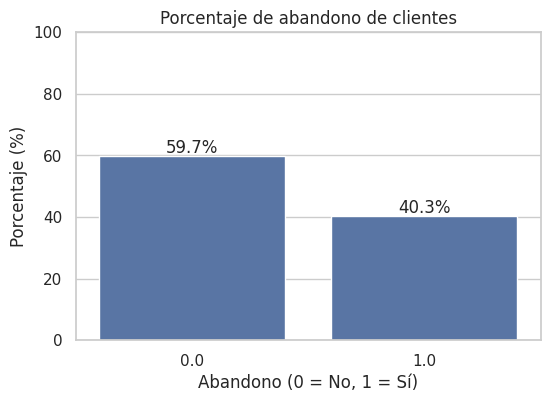

In [25]:
#1. DISTRIBUCIÓN DE ABANDONO

# Calcula el porcentaje de retención (0) y abandono (1) normalizando el conteo y multiplicando por 100
abandono_pct = df['abandono'].value_counts(normalize=True) * 100

# Crea una figura para el gráfico especificando su tamaño en pulgadas (ancho, alto)
plt.figure(figsize=(6,4))

# Genera un gráfico de barras usando los índices (0 y 1) en el eje X y los porcentajes en el eje Y
sns.barplot(
    x=abandono_pct.index,
    y=abandono_pct.values
)

# Añade un título principal en la parte superior del gráfico
plt.title("Porcentaje de abandono de clientes")
# Agrega una etiqueta explicativa al eje X
plt.xlabel("Abandono (0 = No, 1 = Sí)")
# Agrega una etiqueta explicativa al eje Y
plt.ylabel("Porcentaje (%)")

# Itera sobre los valores calculados para poder colocar un texto encima de cada barra
for i, v in enumerate(abandono_pct.values):
    # Dibuja el texto en las coordenadas (x, y), con el valor formateado a 1 decimal y centrado
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

# Establece los límites visuales del eje Y de 0 a 100 para representar el porcentaje completo
plt.ylim(0, 100)

# Renderiza y muestra el gráfico final en pantalla
plt.show()

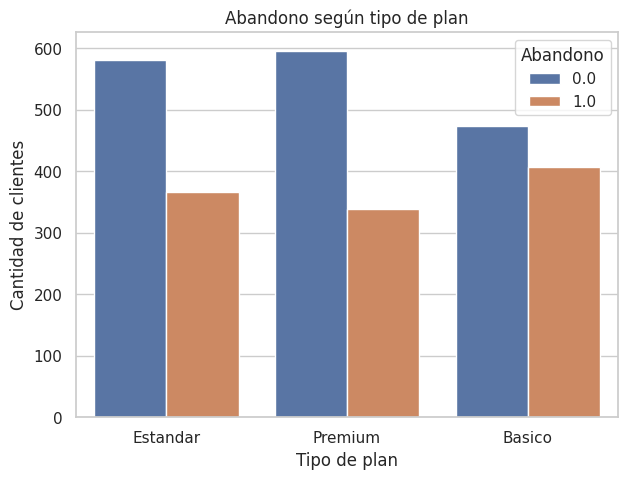

In [26]:
#--------------------------------------------
#2. ABANDONO POR TIPO DE PLAN

plt.figure(figsize=(7,5))
# Genera un gráfico de conteo (barras) separado por categorías (hue) basado en la variable de abandono
sns.countplot(x='tipo_plan', hue='abandono', data=df)

plt.title("Abandono según tipo de plan")
plt.xlabel("Tipo de plan")
plt.ylabel("Cantidad de clientes")

# Configura y muestra la leyenda del gráfico, añadiendo un título específico para esta cajita
plt.legend(title="Abandono")
plt.show()

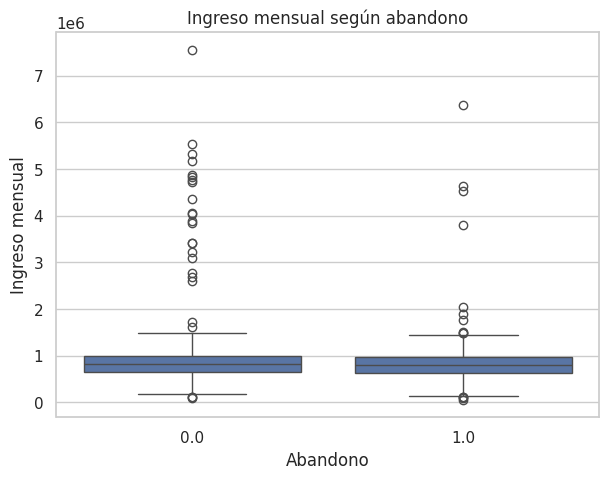

In [27]:
#------------------------------------------
# 3. INGRESO VS ABANDONO

plt.figure(figsize=(7,5))
# Crea un diagrama de caja (boxplot) para observar la distribución de datos y valores atípicos del ingreso según abandono
sns.boxplot(x='abandono', y='ingreso_mensual', data=df)

plt.title("Ingreso mensual según abandono")
plt.xlabel("Abandono")
plt.ylabel("Ingreso mensual")

plt.show()

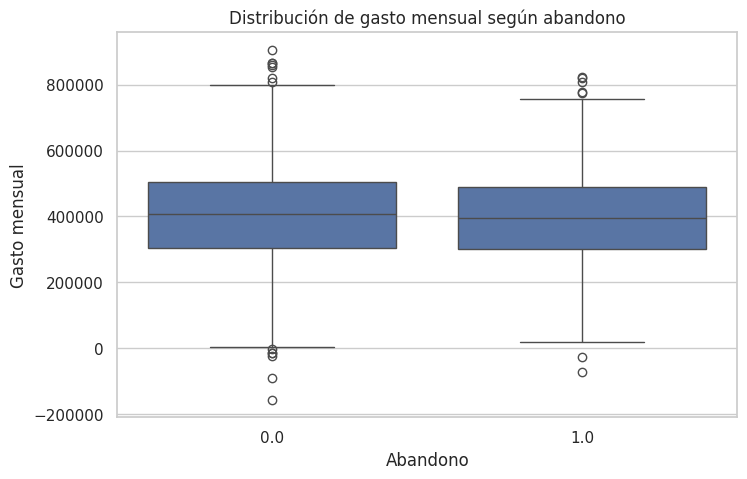

In [28]:
#-------------------------------------------
# 4. GASTO VS ABANDONO
plt.figure(figsize=(8,5))
sns.boxplot(x='abandono', y='gasto_mensual', data=df)

plt.title("Distribución de gasto mensual según abandono")
plt.xlabel("Abandono")
plt.ylabel("Gasto mensual")

plt.show()

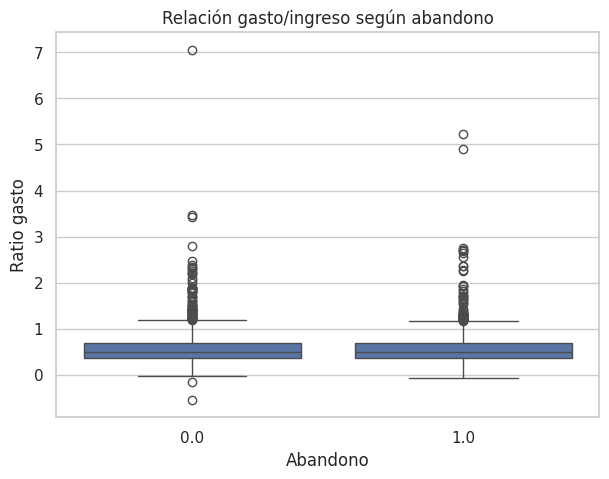

In [29]:
#--------------------------------------------------
# 5. RATIO_GASTO VS ABANDONO

# Crea una nueva columna calculando matemáticamente la proporción del gasto sobre el ingreso en el DataFrame procesado
df_procesado['ratio_gasto'] = df_procesado['gasto_mensual'] / df_procesado['ingreso_mensual']

plt.figure(figsize=(7,5))
sns.boxplot(x='abandono', y='ratio_gasto', data=df_procesado)

plt.title("Relación gasto/ingreso según abandono")
plt.xlabel("Abandono")
plt.ylabel("Ratio gasto")

plt.show()

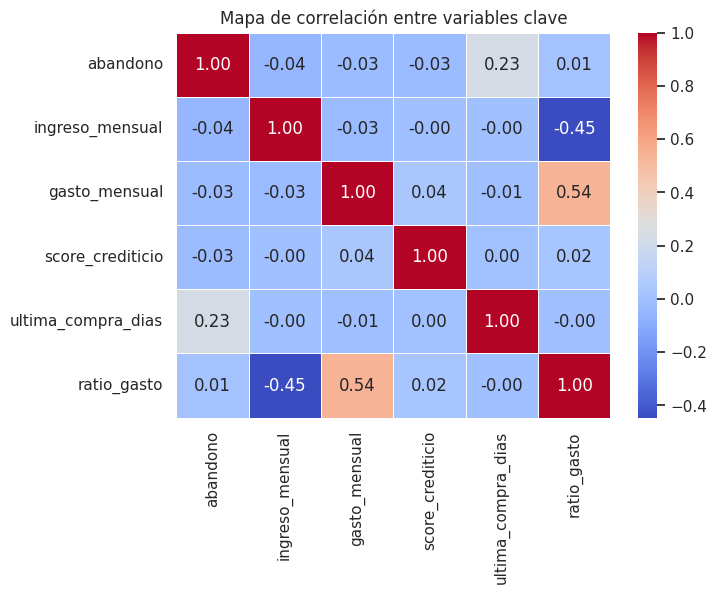

In [30]:
#------------------------------------------------------
# 6. MAPA DE CORRELACION

# Crea una lista con los nombres específicos de las columnas numéricas que se desean cruzar en la matriz
cols = [
    'abandono',
    'ingreso_mensual',
    'gasto_mensual',
    'score_crediticio',
    'ultima_compra_dias',
    'ratio_gasto'
]

plt.figure(figsize=(7,5))

# Genera un mapa de calor (heatmap) usando la matriz de correlación lineal (.corr()) del subconjunto de columnas elegido
sns.heatmap(
    df_procesado[cols].corr(),
    annot=True,          # Imprime el valor numérico exacto de la correlación dentro de cada cuadro
    cmap='coolwarm',     # Aplica una paleta de colores divergente (tonos fríos/azules y cálidos/rojos)
    fmt=".2f",           # Da formato a los números para que solo muestren 2 decimales
    linewidths=0.5,      # Define el grosor de las líneas de separación entre celdas
    linecolor='white'    # Pinta de blanco las líneas divisorias de la cuadrícula
)

plt.title("Mapa de correlación entre variables clave")

plt.show()